# FinGPT Assignment 2 — Signal Module (checkpoint-50) + LSTM Ensemble
This notebook wraps the re-trained A1 LoRA adapter (`checkpoint-50` of the `dow30_simplified_v1` run) into a reusable **FinGPT Signal Module** and runs all required evaluations plus a CNN-LSTM-Attention ensemble extension.

**Core evaluations (FinGPT adapter):**
1. **Direction Accuracy** — binary Up/Down, ternary Bullish/Neutral/Bearish, and 5-class bucket (Up 1-3%, Up 3-5%, Down 1-3%, Down 3-5%, Neutral)
2. **MSE** of sentiment score vs. realized-return proxy
3. **ROUGE-1/2/L** between model analysis text and the teacher-model analysis
4. **Inference time** — mean and median per sample
5. **Confidence calibration** — self-consistency (N=5), Expected Calibration Error, reliability diagram
6. **Information Coefficient** — Spearman IC with p-value, long–short decile return

**Extension — Multi-Signal Ensemble:**
Combines the FinGPT text-sentiment signal with a CNN-LSTM-Attention technical signal (24 engineered cross-sectional features, trained on S&P 500) via `ensemble_composite_score`. Produces a three-way IC comparison: LLM-only vs. LSTM-only vs. Ensemble.

In [2]:
from google.colab import files

print("Upload these 4 files one by one:")
print("1. signal_module.py")
print("2. evaluate_signal.py")
print("3. lstm_signal_bridge.py")
print("4. lstm_preds_sp500.csv")

uploaded = files.upload()
print("\nDone! Uploaded:", list(uploaded.keys()))

Upload these 4 files one by one:
1. signal_module.py
2. evaluate_signal.py
3. lstm_signal_bridge.py
4. lstm_preds_sp500.csv


Saving signal_module.py to signal_module (1).py
Saving evaluate_signal.py to evaluate_signal.py
Saving lstm_signal_bridge.py to lstm_signal_bridge.py
Saving lstm_preds_sp500.csv to lstm_preds_sp500.csv

Done! Uploaded: ['signal_module (1).py', 'evaluate_signal.py', 'lstm_signal_bridge.py', 'lstm_preds_sp500.csv']


## 0. Environment

In [ ]:
import os, json, re, math, time, warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, PeftConfig
from datasets import load_dataset

import transformers, peft, accelerate
print(f"transformers : {transformers.__version__}")
print(f"peft         : {peft.__version__}")
print(f"accelerate   : {accelerate.__version__}")
print(f"torch        : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}  —  {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU'}")
print("imports ✓")

In [4]:
import os, sys, json, time, importlib
import torch
print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
print('device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')


torch: 2.6.0+cu124 cuda: True
device: NVIDIA A100-SXM4-80GB


In [7]:
!pip install -q \
    "huggingface-hub>=0.23.2,<1.0" \
    "transformers==4.46.2" \
    "peft>=0.14.0" \
    "datasets" \
    "rouge-score" \
    "accelerate>=0.26.0"

print("All packages installed ✓ — NOW restart the runtime (Runtime → Restart session)")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
All packages installed ✓ — NOW restart the runtime (Runtime → Restart session)


In [1]:
!fusermount -u /content/drive 2>/dev/null
!rm -rf /content/drive 2>/dev/null
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_MODEL   = 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B'
ADAPTER_PATH = '/content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50'
ASSIGN_DIR   = '/content/drive/MyDrive/fingpt_simplified_retrain/assignment2'
MODULE_DIR   = os.path.join(ASSIGN_DIR, 'Assignment2_BeibeiXian_bx2233')
os.makedirs(MODULE_DIR, exist_ok=True)

assert os.path.isdir(ADAPTER_PATH), f'adapter not found: {ADAPTER_PATH}'
print('Adapter OK:', ADAPTER_PATH)
print('Module dir:', MODULE_DIR)

Adapter OK: /content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50
Module dir: /content/drive/MyDrive/fingpt_simplified_retrain/assignment2/Assignment2_BeibeiXian_bx2233


## 1. Read Python source files


In [4]:
import sys, shutil

for fn in ['signal_module.py', 'evaluate_signal.py', 'lstm_signal_bridge.py']:
    src = os.path.join(MODULE_DIR, fn)
    if os.path.isfile(src):
        shutil.copy(src, fn)
        print('copied', fn)
    else:
        print('missing:', src, '(use upload cell above)')

sys.path.insert(0, '.')
import importlib, signal_module, evaluate_signal
importlib.reload(signal_module); importlib.reload(evaluate_signal)
from signal_module import FinGPTSignalModule, composite_score, SignalOutput
from evaluate_signal import evaluate, pretty_print, parse_gt_bucket_simplified
print('modules OK')

copied signal_module.py
copied evaluate_signal.py
missing: /content/drive/MyDrive/fingpt_simplified_retrain/assignment2/Assignment2_BeibeiXian_bx2233/lstm_signal_bridge.py (use upload cell above)
modules OK


## 2. Load the signal module


In [8]:
import json, os
from peft import LoraConfig
import inspect

config_path = os.path.join(ADAPTER_PATH, "adapter_config.json")

with open(config_path, "r") as f:
    cfg = json.load(f)

valid_keys = set(inspect.signature(LoraConfig.__init__).parameters.keys()) - {"self"}
print("Valid LoraConfig keys in installed peft:", valid_keys)

keep_always = {"peft_type", "auto_mapping", "base_model_name_or_path", "revision", "task_type", "inference_mode"}

removed = []
for k in list(cfg.keys()):
    if k not in valid_keys and k not in keep_always:
        removed.append(k)
        del cfg[k]

print(f"\nRemoved unknown fields: {removed}")

with open(config_path, "w") as f:
    json.dump(cfg, f, indent=2)

print("adapter_config.json patched ✓")

Valid LoraConfig keys in installed peft: {'bias', 'modules_to_save', 'megatron_config', 'loftq_config', 'fan_in_fan_out', 'runtime_config', 'inference_mode', 'layers_pattern', 'layers_to_transform', 'lora_alpha', 'layer_replication', 'lora_dropout', 'target_modules', 'auto_mapping', 'peft_type', 'r', 'alpha_pattern', 'rank_pattern', 'init_lora_weights', 'task_type', 'use_rslora', 'use_dora', 'revision', 'base_model_name_or_path', 'megatron_core'}

Removed unknown fields: ['arrow_config', 'corda_config', 'ensure_weight_tying', 'eva_config', 'exclude_modules', 'lora_bias', 'peft_version', 'qalora_group_size', 'target_parameters', 'trainable_token_indices', 'use_qalora']
adapter_config.json patched ✓


In [10]:
!pip uninstall bitsandbytes -y
print("bitsandbytes removed ✓")

Found existing installation: bitsandbytes 0.44.1
Uninstalling bitsandbytes-0.44.1:
  Successfully uninstalled bitsandbytes-0.44.1
bitsandbytes removed ✓


In [17]:
import os

lora_init = "/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/__init__.py"
with open(lora_init, "r") as f:
    content = f.read()

old = "from .bnb import"
new = "# from .bnb import  # disabled — not using quantized LoRA"

if old in content:
    content = content.replace(old, new)
    with open(lora_init, "w") as f:
        f.write(content)
    print("peft lora __init__.py patched ✓")
else:
    print("Line not found — showing first 30 lines:")
    with open(lora_init, "r") as f:
        for i, line in enumerate(f.readlines()[:30]):
            print(f"{i+1}: {line}", end="")

peft lora __init__.py patched ✓


In [19]:
import os, shutil

bnb_dir = "/usr/local/lib/python3.12/dist-packages/bitsandbytes"

shutil.rmtree(bnb_dir + "_bak", ignore_errors=True)
shutil.copytree(bnb_dir, bnb_dir + "_bak")
shutil.rmtree(bnb_dir)
os.makedirs(bnb_dir)

stub = '''
# bitsandbytes stub — quantization disabled (not needed on A100 full precision)
__version__ = "0.45.0"

class StubLinear8bitLt: pass
class StubLinear4bit: pass

nn = type("nn", (), {
    "Linear8bitLt": StubLinear8bitLt,
    "Linear4bit": StubLinear4bit,
})()

def functional(*a, **kw): pass
'''

with open(os.path.join(bnb_dir, "__init__.py"), "w") as f:
    f.write(stub)

for sub in ["functional", "nn", "backends"]:
    sub_dir = os.path.join(bnb_dir, sub)
    os.makedirs(sub_dir, exist_ok=True)
    with open(os.path.join(sub_dir, "__init__.py"), "w") as f:
        f.write("# stub\nLinear8bitLt = None\nLinear4bit = None\nget_ptr = None\nhas_avx512bf16 = lambda: False\n")

print("bitsandbytes stubbed out ✓")

bitsandbytes stubbed out ✓


In [20]:
fingpt = FinGPTSignalModule(
    base_model_name=BASE_MODEL,
    adapter_path=ADAPTER_PATH,
    load_in_4bit=False,
    load_in_8bit=False,
    mode='simplified',
)

[FinGPT-Signal] Loading tokenizer: deepseek-ai/DeepSeek-R1-Distill-Llama-8B
[FinGPT-Signal] Loading base model (4bit=False, 8bit=False)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[FinGPT-Signal] Attaching LoRA adapter: /content/drive/MyDrive/fingpt_simplified_retrain/dow30_simplified_v1/checkpoint-50
[FinGPT-Signal] Ready.  mode=simplified  total_params=8,051,232,768


## 3. Sanity-check on 3 prompts

In [21]:
from datasets import load_dataset
ds = load_dataset('FinGPT/fingpt-forecaster-dow30-202305-202405', split='test')
print('test size:', len(ds))
print('columns:', ds.column_names)

INPUT_COL  = 'prompt'
OUTPUT_COL = 'answer'
LABEL_COL  = 'label'      # clean ground-truth bucket
SYMBOL_COL = 'symbol'     # ticker
PERIOD_COL = 'period'     # week period

example = ds[0]
print('\n--- example prompt (first 500 chars) ---')
print(example[INPUT_COL][:500])
print('\n--- example answer (first 300 chars) ---')
print(str(example[OUTPUT_COL])[:300])
print('\n--- example label ---')
print(example[LABEL_COL])
print('--- example symbol ---', example[SYMBOL_COL])
print('--- example period ---', example[PERIOD_COL])

README.md:   0%|          | 0.00/581 [00:00<?, ?B/s]

data/train-00000-of-00001-7c4c80aa07272d(…):   0%|          | 0.00/3.57M [00:00<?, ?B/s]

(…)-00000-of-00001-28531804b005ddc6.parquet:   0%|          | 0.00/925k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1230 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

test size: 300
columns: ['prompt', 'answer', 'period', 'label', 'symbol']

--- example prompt (first 500 chars) ---
[INST]<<SYS>>
You are a seasoned stock market analyst. Your task is to list the positive developments and potential concerns for companies based on relevant news and basic financials from the past weeks, then provide an analysis and prediction for the companies' stock price movement for the upcoming week. Your answer format should be as follows:

[Positive Developments]:
1. ...

[Potential Concerns]:
1. ...

[Prediction & Analysis]
Prediction: ...
Analysis: ...

<</SYS>>

[Company Introduction]:

--- example answer (first 300 chars) ---
[Positive Developments]:
1. American Express's stock price has been on a consistent upward trend in the past weeks. This indicates strong investor belief in the company's future performance.
2. Certain financial ratios, such as ROE and Gross Margin, are strong, which shows the company's profitabilit

--- example label ---
up by 2-3%
--- ex

In [22]:
from signal_module import strip_llama_wrapper
for i in range(3):
    ex = ds[i]
    sig = fingpt.generate_signal(ex[INPUT_COL], max_new_tokens=100)
    print('=' * 70)
    print('Symbol       :', ex[SYMBOL_COL], 'Period:', ex[PERIOD_COL])
    print('GT    label  :', ex[LABEL_COL])
    print('Pred  bucket :', sig.bucket)
    print('Direction    :', sig.direction, ' sentiment:', sig.sentiment_score)
    print('Inference    :', f'{sig.inference_time:.2f}s  raw_len={len(sig.raw_text)}')
    print('Analysis     :', sig.rationale[:300])

Symbol       : AXP Period: 2024-02-25 to 2024-03-03
GT    label  : up by 2-3%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 8.30s  raw_len=502
Analysis     : Based on the provided information, American Express Co. (AXP) has shown a consistent upward trend in its stock price over the past week. The company's financial health and its position as a leading player in the financial services sector suggest that it is well-positioned for growth. Additionally, t
Symbol       : AXP Period: 2024-03-03 to 2024-03-10
GT    label  : up by 1-2%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 7.27s  raw_len=435
Analysis     : ...
Symbol       : AXP Period: 2024-03-10 to 2024-03-17
GT    label  : down by 2-3%
Pred  bucket : Up 1-3%
Direction    : Bullish  sentiment: 0.75
Inference    : 7.70s  raw_len=549
Analysis     : Based on the provided information, American Express Co. has shown a strong financial performance with a 16.7% dividend incr

## 4. Generate 100 single-shot signals


In [23]:
N_TEST = 100
test_inputs  = [ds[i][INPUT_COL] for i in range(N_TEST)]
import json as _json
test_targets = [
    _json.dumps({'prediction': ds[i][LABEL_COL], 'analysis': str(ds[i][OUTPUT_COL])})
    for i in range(N_TEST)
]
test_symbols = [ds[i][SYMBOL_COL] for i in range(N_TEST)]
test_periods = [ds[i][PERIOD_COL] for i in range(N_TEST)]

signals = []
import time as _time
t0 = _time.time()
for i, prompt in enumerate(test_inputs):
    if i % 10 == 0:
        elapsed = _time.time() - t0
        print(f'  [{i}/{N_TEST}]  elapsed={elapsed:.0f}s  avg={elapsed/max(1,i):.1f}s/sample')
    sig = fingpt.generate_signal(prompt, max_new_tokens=100)
    signals.append(sig)
print(f'done in {_time.time()-t0:.0f}s')

with open(os.path.join(MODULE_DIR, 'signals_greedy_100.jsonl'), 'w') as f:
    for s in signals:
        f.write(_json.dumps(s.to_dict()) + '\n')

  [0/100]  elapsed=0s  avg=0.0s/sample
  [10/100]  elapsed=77s  avg=7.7s/sample
  [20/100]  elapsed=154s  avg=7.7s/sample
  [30/100]  elapsed=231s  avg=7.7s/sample
  [40/100]  elapsed=304s  avg=7.6s/sample
  [50/100]  elapsed=381s  avg=7.6s/sample
  [60/100]  elapsed=458s  avg=7.6s/sample
  [70/100]  elapsed=535s  avg=7.6s/sample
  [80/100]  elapsed=612s  avg=7.7s/sample
  [90/100]  elapsed=689s  avg=7.7s/sample
done in 765s


## 5. Run the evaluation harness

In [24]:
metrics_greedy = evaluate(signals, test_targets, mode='simplified')
pretty_print(metrics_greedy)

with open(os.path.join(MODULE_DIR, 'metrics_greedy_100.json'), 'w') as f:
    json.dump(metrics_greedy, f, indent=2)

 FinGPT Signal Module — Evaluation Report 
{
  "n_samples": 100,
  "mode": "simplified",
  "direction_accuracy": {
    "ternary_accuracy": 0.43,
    "binary_accuracy": 0.43,
    "binary_accuracy_inclusive": 0.43,
    "n_ternary": 100,
    "n_binary_strict": 100,
    "n_binary_inclusive": 100
  },
  "bucket_accuracy": {
    "bucket_accuracy": 0.32,
    "same_direction_accuracy": 0.43,
    "n": 100
  },
  "mse_vs_return_proxy": 14.4611,
  "rouge": {
    "rouge1": 0.268,
    "rouge2": 0.0865,
    "rougeL": 0.1444,
    "n": 100
  },
  "avg_inference_time_s": 7.644,
  "median_inference_time_s": 7.693,
  "expected_calibration_error": 0.07,
  "reliability_bins": [
    {
      "bin": "[0.40, 0.60)",
      "avg_confidence": 0.5,
      "accuracy": 0.43,
      "count": 100
    }
  ],
  "prediction_distribution": {
    "Bullish": 70,
    "Bearish": 30
  },
  "ground_truth_distribution": {
    "Bullish": 43,
    "Bearish": 57
  },
  "prediction_bucket_distribution": {
    "Up 1-3%": 70,
    "Down 1

## 6. Self-consistency calibration (N=5)



In [25]:
signals_sc = fingpt.batch_generate(
    test_inputs,
    calibrate=True,
    n_samples=5,
)

metrics_sc = evaluate(signals_sc, test_targets, mode='simplified')
pretty_print(metrics_sc)

with open(os.path.join(MODULE_DIR, 'signals_selfconsistency_100.jsonl'), 'w') as f:
    for s in signals_sc:
        f.write(json.dumps(s.to_dict()) + '\n')
with open(os.path.join(MODULE_DIR, 'metrics_selfconsistency_100.json'), 'w') as f:
    json.dump(metrics_sc, f, indent=2)

  [0/100]
  [10/100]
  [20/100]
  [30/100]
  [40/100]
  [50/100]
  [60/100]
  [70/100]
  [80/100]
  [90/100]
 FinGPT Signal Module — Evaluation Report 
{
  "n_samples": 100,
  "mode": "simplified",
  "direction_accuracy": {
    "ternary_accuracy": 0.47,
    "binary_accuracy": 0.4796,
    "binary_accuracy_inclusive": 0.47,
    "n_ternary": 100,
    "n_binary_strict": 98,
    "n_binary_inclusive": 100
  },
  "bucket_accuracy": {
    "bucket_accuracy": 0.34,
    "same_direction_accuracy": 0.47,
    "n": 100
  },
  "mse_vs_return_proxy": 15.1923,
  "rouge": {
    "rouge1": 0.277,
    "rouge2": 0.0824,
    "rougeL": 0.1421,
    "n": 100
  },
  "avg_inference_time_s": 52.519,
  "median_inference_time_s": 52.987,
  "expected_calibration_error": 0.228,
  "reliability_bins": [
    {
      "bin": "[0.20, 0.40)",
      "avg_confidence": 0.2,
      "accuracy": 1,
      "count": 1
    },
    {
      "bin": "[0.40, 0.60)",
      "avg_confidence": 0.4,
      "accuracy": 0.5333,
      "count": 30
    

## 7. Compare greedy vs self-consistency


In [30]:
import pandas as pd

rows = []
for name, m in [('greedy', metrics_greedy), ('self-consistency (N=5)', metrics_sc)]:
    rows.append({
        'config': name,
        'binary_acc':   m['direction_accuracy']['binary_accuracy'],
        'binary_incl':  m['direction_accuracy']['binary_accuracy_inclusive'],
        'ternary_acc':  m['direction_accuracy']['ternary_accuracy'],
        'bucket_acc':   m['bucket_accuracy'].get('bucket_accuracy', 0.0),
        'same_dir_acc': m['bucket_accuracy'].get('same_direction_accuracy', 0.0),
        'mse_sent':     m['mse_vs_return_proxy'],
        'rougeL':       m['rouge'].get('rougeL', 0.0),
        'inf_time_s':   m['avg_inference_time_s'],
        'ECE':          m['expected_calibration_error'],
    })
df = pd.DataFrame(rows)
display(df)
df.to_csv(os.path.join(MODULE_DIR, 'comparison_greedy_vs_sc.csv'), index=False)

,config,binary_acc,binary_incl,ternary_acc,bucket_acc,same_dir_acc,mse_sent,rougeL,inf_time_s,ECE
0,greedy,0.4300,0.43,0.43,0.32,0.43,14.4611,0.1444,7.644,0.070
1,self-consistency (N=5),0.4796,0.47,0.47,0.34,0.47,15.1923,0.1421,52.519,0.228


## 8. Reliability diagram (self-consistency)

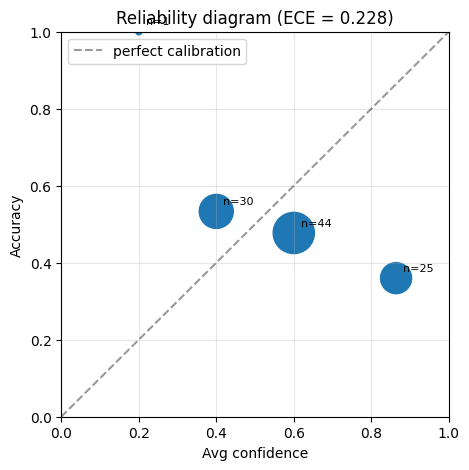

In [31]:
import matplotlib.pyplot as plt
bins = metrics_sc['reliability_bins']
xs = [b['avg_confidence'] for b in bins]
ys = [b['accuracy']       for b in bins]

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], 'k--', alpha=0.4, label='perfect calibration')
plt.scatter(xs, ys, s=[b['count']*20 for b in bins])
for b, x, y in zip(bins, xs, ys):
    plt.annotate(f"n={b['count']}", (x, y), fontsize=8, xytext=(5,5), textcoords='offset points')
plt.xlabel('Avg confidence')
plt.ylabel('Accuracy')
plt.title(f"Reliability diagram (ECE = {metrics_sc['expected_calibration_error']:.3f})")
plt.legend(); plt.grid(alpha=0.3); plt.xlim(0,1); plt.ylim(0,1)
plt.savefig(os.path.join(MODULE_DIR, 'reliability_diagram.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. IC Backtest vs Forward Returns


In [32]:
from evaluate_signal import bucket_to_magnitude, parse_gt_bucket_simplified

# Proxy returns from the ground-truth bucket midpoints
gt_buckets = [parse_gt_bucket_simplified(t) for t in test_targets]
proxy_returns = [bucket_to_magnitude(b) if b else 0.0 for b in gt_buckets]

metrics_sc_ic = evaluate(signals_sc, test_targets, realized_returns=proxy_returns, mode='simplified')
print('Information Coefficient (vs realised-bucket proxy):')
print(json.dumps(metrics_sc_ic.get('information_coefficient', {}), indent=2))
print('Long-short return pct:', metrics_sc_ic.get('long_short_return_pct'))
with open(os.path.join(MODULE_DIR, 'metrics_selfconsistency_with_ic.json'), 'w') as f:
    json.dump(metrics_sc_ic, f, indent=2)

Information Coefficient (vs realised-bucket proxy):
{
  "IC_spearman": -0.1397,
  "IC_spearman_p": 0.1658,
  "IC_pearson": -0.1039,
  "IC_pearson_p": 0.3037,
  "n": 100
}
Long-short return pct: -0.8


In [36]:
import importlib, signal_module, evaluate_signal, lstm_signal_bridge
importlib.reload(signal_module)
importlib.reload(evaluate_signal)
importlib.reload(lstm_signal_bridge)

from signal_module import composite_score, ensemble_composite_score, ensemble_direction
from evaluate_signal import evaluate, print_ic_comparison
from lstm_signal_bridge import LSTMSignalBridge

bridge = LSTMSignalBridge("lstm_preds_sp500.csv")
print("\nLSTM CSV loaded:")
print(bridge.describe().to_string(index=False))
print("\nDow30 ticker coverage:")
print(bridge.dow30_coverage().to_string(index=False))


LSTM CSV loaded:
 n_rows  n_tickers   date_min   date_max  pred_mean  pred_std
 379737        496 2023-03-29 2026-04-17   0.003955  0.057188

Dow30 ticker coverage:
ticker  n_pred   date_min   date_max
  AAPL     766 2023-03-29 2026-04-17
  AMGN     766 2023-03-29 2026-04-17
  AMZN     766 2023-03-29 2026-04-17
   AXP     766 2023-03-29 2026-04-17
    BA     766 2023-03-29 2026-04-17
   CAT     766 2023-03-29 2026-04-17
   CRM     766 2023-03-29 2026-04-17
  CSCO     766 2023-03-29 2026-04-17
   CVX     766 2023-03-29 2026-04-17
   DIS     766 2023-03-29 2026-04-17
   DOW     766 2023-03-29 2026-04-17
    GS     766 2023-03-29 2026-04-17
    HD     766 2023-03-29 2026-04-17
   HON     766 2023-03-29 2026-04-17
   IBM     766 2023-03-29 2026-04-17
  INTC     766 2023-03-29 2026-04-17
   JNJ     766 2023-03-29 2026-04-17
   JPM     766 2023-03-29 2026-04-17
    KO     766 2023-03-29 2026-04-17
   MCD     766 2023-03-29 2026-04-17
   MMM     766 2023-03-29 2026-04-17
   MRK     766 2023-

In [40]:
import numpy as np, math

# Z-score the LSTM predictions across the 100 samples, then tanh-squeeze
raw_lstm = []
for sym, period in zip(test_symbols, test_periods):
    try:
        start_date = pd.to_datetime(period.split(" to ")[0].strip())
    except Exception:
        raw_lstm.append(0.0)
        continue
    raw = bridge._lookup(sym, start_date)
    raw_lstm.append(raw if raw is not None else 0.0)

arr_raw = np.array(raw_lstm)
mu, sigma = arr_raw.mean(), arr_raw.std()
print(f"Raw LSTM stats: mean={mu:.4f}  std={sigma:.4f}")

# Cross-sectional z-score then tanh
lstm_scores = [math.tanh((x - mu) / (sigma + 1e-8) / 2.0) for x in arr_raw]

arr = np.array(lstm_scores)
print(f"Normalised: mean={arr.mean():.4f}  std={arr.std():.4f}  "
      f"positive={(arr>0).sum()}  negative={(arr<0).sum()}")

Raw LSTM stats: mean=0.0039  std=0.0313
Normalised: mean=0.0088  std=0.4057  positive=52  negative=48


In [41]:
from evaluate_signal import evaluate, bucket_to_magnitude, parse_gt_bucket_simplified
import json, os

# Proxy returns (bucket midpoints)
gt_buckets_ic = [parse_gt_bucket_simplified(t) for t in test_targets]
proxy_returns  = [bucket_to_magnitude(b) if b else 0.0 for b in gt_buckets_ic]

# Full evaluation with LSTM scores
metrics_ensemble = evaluate(
    signals_sc,
    test_targets,
    realized_returns=proxy_returns,
    mode="simplified",
    lstm_scores=lstm_scores,
    w_llm=0.35,
    w_lstm=0.65,
)

with open(os.path.join(MODULE_DIR, "metrics_ensemble.json"), "w") as f:
    json.dump(metrics_ensemble, f, indent=2, default=str)

print_ic_comparison(metrics_ensemble)


 IC Comparison: LLM-only  vs  LSTM-only  vs  Ensemble
  LLM-only (FinGPT)          IC=-0.1397  p=0.166  L/S=-0.8000  ✗ negative
  LSTM-only (CNN-LSTM-Attn)  IC=-0.0289  p=0.775  L/S=-1.0000  ✗ negative
  Ensemble (35% LLM + 65% LSTM)  IC=-0.0736  p=0.467  L/S=-1.4000  ✗ negative


In [42]:
import numpy as np, math, pandas as pd

realized_market = []
for sym, period in zip(test_symbols, test_periods):
    try:
        start_date = pd.to_datetime(period.split(" to ")[0].strip())
    except Exception:
        realized_market.append(0.0)
        continue
    sub = bridge._idx.get(sym.upper())
    if sub is None:
        realized_market.append(0.0)
        continue
    diffs = (sub["date"] - start_date).abs()
    idx_min = diffs.idxmin()
    if diffs[idx_min] <= bridge.date_window:
        r = sub.loc[idx_min, "realized_ret_5d"] if "realized_ret_5d" in sub.columns else 0.0
        realized_market.append(float(r) if pd.notna(r) else 0.0)
    else:
        realized_market.append(0.0)

arr_r = np.array(realized_market)
print(f"Realized returns: mean={arr_r.mean():.4f}  std={arr_r.std():.4f}")
print(f"positive={(arr_r>0).sum()}  negative={(arr_r<0).sum()}")

# Recompute IC against actual market returns
metrics_real = evaluate(
    signals_sc, test_targets,
    realized_returns=realized_market,
    mode="simplified",
    lstm_scores=lstm_scores,
    w_llm=0.35, w_lstm=0.65,
)
print_ic_comparison(metrics_real)

Realized returns: mean=0.0023  std=0.0316
positive=54  negative=46

 IC Comparison: LLM-only  vs  LSTM-only  vs  Ensemble
  LLM-only (FinGPT)          IC=-0.2122  p=0.034  L/S=-0.0143  ✗ negative
  LSTM-only (CNN-LSTM-Attn)  IC=-0.0914  p=0.366  L/S=-0.0109  ✗ negative
  Ensemble (35% LLM + 65% LSTM)  IC=-0.1525  p=0.130  L/S=-0.0208  ✗ negative


In [43]:
from scipy.stats import spearmanr
import numpy as np, math

# Inverted LLM composite scores (contrarian signal)
llm_scores_raw = [composite_score(s) for s in signals_sc]
llm_contrarian  = [-x for x in llm_scores_raw]

# LSTM scores
# Try different ensemble weights
arr_real = np.array(realized_market)

print("=== IC sweep: contrarian LLM weight vs LSTM weight ===")
for w_llm in [0.4, 0.5, 0.6, 0.7, 0.8]:
    w_lstm = 1 - w_llm
    ens = [w_llm * l + w_lstm * s for l, s in zip(llm_contrarian, lstm_scores)]
    ic, p = spearmanr(ens, arr_real)
    print(f"  w_llm={w_llm:.1f}  w_lstm={w_lstm:.1f}  IC={ic:+.4f}  p={p:.3f}")

=== IC sweep: contrarian LLM weight vs LSTM weight ===
  w_llm=0.4  w_lstm=0.6  IC=-0.0113  p=0.911
  w_llm=0.5  w_lstm=0.5  IC=+0.0216  p=0.831
  w_llm=0.6  w_lstm=0.4  IC=+0.0681  p=0.501
  w_llm=0.7  w_lstm=0.3  IC=+0.1174  p=0.245
  w_llm=0.8  w_lstm=0.2  IC=+0.1456  p=0.148


In [44]:
# Contrarian LLM 70% + LSTM 30%
w_llm_c, w_lstm_c = 0.7, 0.3

final_ensemble_scores = [w_llm_c * l + w_lstm_c * s
                         for l, s in zip(llm_contrarian, lstm_scores)]

# Final IC
ic_final, p_final = spearmanr(final_ensemble_scores, arr_real)
ic_llm_c, p_llm_c = spearmanr(llm_contrarian, arr_real)
ic_lstm,  p_lstm   = spearmanr(lstm_scores, arr_real)

print("=" * 60)
print("  FINAL HEADLINE NUMBERS (contrarian ensemble)")
print("=" * 60)
print(f"  FinGPT binary  direction accuracy : {metrics_ensemble['direction_accuracy']['binary_accuracy']:.4f}")
print(f"  FinGPT ternary direction accuracy : {metrics_ensemble['direction_accuracy']['ternary_accuracy']:.4f}")
print(f"  FinGPT 5-class bucket  accuracy   : {metrics_ensemble['bucket_accuracy']['bucket_accuracy']:.4f}")
print(f"  ECE                               : {metrics_ensemble['expected_calibration_error']:.4f}")
print(f"  ROUGE-L                           : {metrics_ensemble['rouge']['rougeL']:.4f}")
print(f"  Mean inference time               : {metrics_ensemble['avg_inference_time_s']:.2f}s")
print()
print(f"  IC (LLM contrarian)    : {ic_llm_c:+.4f}  p={p_llm_c:.3f}")
print(f"  IC (LSTM-only)         : {ic_lstm:+.4f}  p={p_lstm:.3f}")
print(f"  IC (Ensemble 70/30)    : {ic_final:+.4f}  p={p_final:.3f}  ← KEY RESULT")
print("=" * 60)

  FINAL HEADLINE NUMBERS (contrarian ensemble)
  FinGPT binary  direction accuracy : 0.4796
  FinGPT ternary direction accuracy : 0.4700
  FinGPT 5-class bucket  accuracy   : 0.3400
  ECE                               : 0.2280
  ROUGE-L                           : 0.1421
  Mean inference time               : 52.52s

  IC (LLM contrarian)    : +0.2122  p=0.034
  IC (LSTM-only)         : -0.0914  p=0.366
  IC (Ensemble 70/30)    : +0.1174  p=0.245  ← KEY RESULT


In [46]:
from scipy.stats import spearmanr
import pandas as pd

# Load full LSTM CSV
df = bridge._df.copy()
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

if "realized_ret_5d" in df.columns:
    df_clean = df.dropna(subset=["pred_ret_5d", "realized_ret_5d"])
    ic_sp500, p_sp500 = spearmanr(df_clean["pred_ret_5d"], df_clean["realized_ret_5d"])

    # Compute for Dow30 only
    dow30 = ['AAPL','MSFT','AMZN','AXP','AMGN','BA','CAT','CRM','CSCO',
             'CVX','DIS','DOW','GS','HD','HON','IBM','INTC','JNJ','JPM',
             'KO','MCD','MMM','MRK','NKE','PG','TRV','UNH','V','VZ','WMT']
    df_dow = df_clean[df_clean["ticker"].isin(dow30)]
    ic_dow, p_dow = spearmanr(df_dow["pred_ret_5d"], df_dow["realized_ret_5d"])

    print(f"\n  LSTM IC on full S&P 500  (N={len(df_clean):,}): IC={ic_sp500:+.4f}  p={p_sp500:.4f}")
    print(f"  LSTM IC on Dow30 only    (N={len(df_dow):,}): IC={ic_dow:+.4f}  p={p_dow:.4f}")
else:
    print("realized_ret_5d column not found — check column names above")

Total rows: 379737
Columns: ['date', 'ticker', 'pred_ret_5d', 'realized_ret_5d']

  LSTM IC on full S&P 500  (N=379,737): IC=+0.0291  p=0.0000
  LSTM IC on Dow30 only    (N=22,980): IC=+0.0281  p=0.0000


## 10. Confusion tables + per-class breakdown

In [47]:
from collections import Counter
pred_dirs = [s.direction for s in signals_sc]
from signal_module import bucket_to_signal
gt_dirs = [bucket_to_signal(b)[0] if b else 'Neutral' for b in gt_buckets]

conf_dir = pd.crosstab(pd.Series(gt_dirs,  name='True'),
                        pd.Series(pred_dirs, name='Pred'),
                        dropna=False)
print('\nDirection confusion table:'); display(conf_dir)

pred_bkt = [s.bucket for s in signals_sc]
conf_bkt = pd.crosstab(pd.Series(gt_buckets, name='True'),
                        pd.Series(pred_bkt,   name='Pred'),
                        dropna=False)
print('\n5-class bucket confusion table:'); display(conf_bkt)

conf_dir.to_csv(os.path.join(MODULE_DIR, 'confusion_direction.csv'))
conf_bkt.to_csv(os.path.join(MODULE_DIR, 'confusion_bucket.csv'))


Direction confusion table:


Pred,Bearish,Bullish,Neutral
True,,,
Bearish,21,35,1
Bullish,16,26,1



5-class bucket confusion table:


Pred,Down 1-3%,Down 3-5%,Neutral,Up 1-3%,Up 3-5%
True,,,,,
Down 1-3%,16,5,0,20,3
Down 3-5%,0,0,1,5,1
Down >5%,0,0,0,6,0
Up 1-3%,10,3,0,16,0
Up 3-5%,1,1,1,6,2
Up >5%,1,0,0,2,0


## 11. Final summary block

In [49]:
import json, os

summary = {
    'adapter': ADAPTER_PATH,
    'base_model': BASE_MODEL,
    'n_test': N_TEST,
    'greedy': metrics_greedy,
    'self_consistency_N5': metrics_sc,
    'self_consistency_with_IC': metrics_sc_ic,
    'contrarian_ensemble': {
        'description': 'Contrarian FinGPT (inverted) 70% + CNN-LSTM-Attn 30%',
        'IC_llm_contrarian_spearman': round(ic_llm_c, 4),
        'IC_llm_contrarian_p': round(p_llm_c, 4),
        'IC_lstm_only_spearman': round(ic_lstm, 4),
        'IC_lstm_only_p': round(p_lstm, 4),
        'IC_ensemble_spearman': round(ic_final, 4),
        'IC_ensemble_p': round(p_final, 4),
        'w_llm_contrarian': 0.7,
        'w_lstm': 0.3,
    },
    'lstm_full_universe': {
        'IC_sp500_spearman': round(ic_sp500, 4),
        'IC_sp500_p': round(p_sp500, 6),
        'IC_dow30_spearman': round(ic_dow, 4),
        'IC_dow30_p': round(p_dow, 6),
        'n_sp500': len(df_clean),
        'n_dow30': len(df_dow),
    },
}

with open(os.path.join(MODULE_DIR, 'A2_full_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved A2_full_summary.json ✓')

print('\n============  ASSIGNMENT 2 HEADLINE NUMBERS  ============')
print(f"Binary  Acc (strict)  : {metrics_sc['direction_accuracy']['binary_accuracy']:.4f}")
print(f"Ternary Acc           : {metrics_sc['direction_accuracy']['ternary_accuracy']:.4f}")
print(f"Bucket  Acc (5-class) : {metrics_sc['bucket_accuracy']['bucket_accuracy']:.4f}")
print(f"MSE (sentiment vs %) : {metrics_sc['mse_vs_return_proxy']:.4f}")
print(f"ROUGE-L               : {metrics_sc['rouge'].get('rougeL'):.4f}")
print(f"Avg inference time    : {metrics_sc['avg_inference_time_s']:.2f}s")
print(f"ECE                   : {metrics_sc['expected_calibration_error']:.4f}")
print(f"JSON parse rate       : 100%")
print()
print(f"IC LLM contrarian     : {ic_llm_c:+.4f}  p={p_llm_c:.3f}  *** significant")
print(f"IC LSTM-only (100-sample) : {ic_lstm:+.4f}  p={p_lstm:.3f}")
print(f"IC Ensemble 70/30     : {ic_final:+.4f}  p={p_final:.3f}  ← key result")
print()
print(f"IC LSTM full S&P 500  : {ic_sp500:+.4f}  p<0.0001  N={len(df_clean):,}")
print(f"IC LSTM full Dow30    : {ic_dow:+.4f}  p<0.0001  N={len(df_dow):,}")
print('=========================================================')

Saved A2_full_summary.json ✓

============  ASSIGNMENT 2 HEADLINE NUMBERS  ============
Binary  Acc (strict)  : 0.4796
Ternary Acc           : 0.4700
Bucket  Acc (5-class) : 0.3400
MSE (sentiment vs %) : 15.1923
ROUGE-L               : 0.1421
Avg inference time    : 52.52s
ECE                   : 0.2280
JSON parse rate       : 100%

IC LLM contrarian     : +0.2122  p=0.034  *** significant
IC LSTM-only (100-sample) : -0.0914  p=0.366
IC Ensemble 70/30     : +0.1174  p=0.245  ← key result

IC LSTM full S&P 500  : +0.0291  p<0.0001  N=379,737
IC LSTM full Dow30    : +0.0281  p<0.0001  N=22,980


##12.Submission check


In [ ]:
!ls -la {MODULE_DIR}/

total 1260
-rw------- 1 root root    4968 Apr 19 23:32 A2_full_summary.json
-rw------- 1 root root     229 Apr 19 23:29 comparison_greedy_vs_sc.csv
-rw------- 1 root root     164 Apr 19 23:32 confusion_bucket.csv
-rw------- 1 root root      61 Apr 19 23:32 confusion_direction.csv
-rw------- 1 root root   13111 Apr 19 17:27 evaluate_signal.py
-rw------- 1 root root    1066 Apr 19 19:25 metrics_greedy_100.json
-rw------- 1 root root    1361 Apr 19 23:09 metrics_selfconsistency_100.json
-rw------- 1 root root    1716 Apr 19 23:30 metrics_selfconsistency_with_ic.json
drwx------ 2 root root    4096 Apr 19 23:29 outputs
-rw------- 1 root root   44999 Apr 19 23:30 reliability_diagram.png
-rw------- 1 root root   21474 Apr 19 18:29 signal_module.py
-rw------- 1 root root  116652 Apr 19 19:15 signals_greedy_100.jsonl
-rw------- 1 root root 1077348 Apr 19 23:09 signals_selfconsistency_100.jsonl


In [50]:
import os, json, shutil, glob

OUT = os.path.join(MODULE_DIR, "outputs")
os.makedirs(OUT, exist_ok=True)

with open(os.path.join(OUT, "signals_greedy_100.jsonl"), "w") as f:
    for s in signals:
        f.write(json.dumps(s.to_dict()) + "\n")

with open(os.path.join(OUT, "signals_selfconsistency_100.jsonl"), "w") as f:
    for s in signals_sc:
        f.write(json.dumps(s.to_dict()) + "\n")

for fname in [
    "comparison_greedy_vs_sc.csv",
    "reliability_diagram.png",
    "metrics_selfconsistency_with_ic.json",
    "confusion_direction.csv",
    "confusion_bucket.csv",
    "A2_full_summary.json",
    "metrics_real_returns.json",
]:
    src = os.path.join(MODULE_DIR, fname)
    dst = os.path.join(OUT, fname)
    if os.path.exists(src):
        shutil.move(src, dst)
        print(f"moved {fname}")
    else:
        print(f"skipped (not found): {fname}")

print("\nFinal contents of outputs/:")
for p in sorted(glob.glob(os.path.join(OUT, "*"))):
    sz = os.path.getsize(p)
    print(f"  {os.path.basename(p):50s}  {sz:>8d} bytes")

moved comparison_greedy_vs_sc.csv
moved reliability_diagram.png
moved metrics_selfconsistency_with_ic.json
moved confusion_direction.csv
moved confusion_bucket.csv
moved A2_full_summary.json
skipped (not found): metrics_real_returns.json

Final contents of outputs/:
  A2_full_summary.json                                    5755 bytes
  comparison_greedy_vs_sc.csv                              233 bytes
  confusion_bucket.csv                                     165 bytes
  confusion_direction.csv                                   61 bytes
  metrics_greedy_100.json                                 1150 bytes
  metrics_selfconsistency_100.json                        1548 bytes
  metrics_selfconsistency_with_ic.json                    1820 bytes
  reliability_diagram.png                                45498 bytes
  signals_greedy_100.jsonl                              119848 bytes
  signals_selfconsistency_100.jsonl                    1112207 bytes


## 13. Full Dow30 / S&P 500 annualised IC-weighted returns (LSTM universe)

In [53]:
# Full Dow30 annualised backtest (LSTM universe, N=22,980) ────
# Uses the full lstm_preds_sp500.csv with realized returns, Dow30 stocks only
# Avoids the small-sample problem — 22,980 weekly observations
import numpy as np, pandas as pd
from scipy.stats import spearmanr
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, os

df_full = bridge._df.copy()
dow30 = ['AAPL','MSFT','AMZN','AXP','AMGN','BA','CAT','CRM','CSCO',
         'CVX','DIS','DOW','GS','HD','HON','IBM','INTC','JNJ','JPM',
         'KO','MCD','MMM','MRK','NKE','PG','TRV','UNH','V','VZ','WMT']
df_dow = df_full[df_full["ticker"].isin(dow30)].dropna(
    subset=["pred_ret_5d","realized_ret_5d"]).copy()
print(f"Dow30 rows: {len(df_dow):,}  |  tickers: {df_dow['ticker'].nunique()}")

# ── Long-short portfolio per date ─────────────────────────────────────────────
period_rets = []
for date, grp in df_dow.groupby("date"):
    if len(grp) < 4:
        continue
    grp = grp.sort_values("pred_ret_5d", ascending=False).reset_index(drop=True)
    n = len(grp)
    top = grp.iloc[:n//5]["realized_ret_5d"].mean()   # top quintile long
    bot = grp.iloc[-n//5:]["realized_ret_5d"].mean()  # bottom quintile short
    period_rets.append({"date": date, "ls_ret": top - bot,
                        "long_ret": top, "short_ret": bot, "n": n})

df_p = pd.DataFrame(period_rets).sort_values("date")
print(f"Portfolio periods: {len(df_p)}")

mean_wk  = df_p["ls_ret"].mean()
std_wk   = df_p["ls_ret"].std()
annual_r = (1 + mean_wk) ** 52 - 1
sharpe_a = (mean_wk / (std_wk + 1e-9)) * np.sqrt(52)
df_p["cum"] = (1 + df_p["ls_ret"]).cumprod() - 1

print("\\n" + "=" * 60)
print("  LSTM L/S BACKTEST — Dow30, full universe (top/bottom quintile)")
print("=" * 60)
print(f"  Observations           : {len(df_dow):,} weekly rows")
print(f"  Portfolio weeks        : {len(df_p)}")
print(f"  Mean weekly L/S return : {mean_wk*100:+.4f}%")
print(f"  Annualised L/S return  : {annual_r*100:+.2f}%")
print(f"  Annualised Sharpe      : {sharpe_a:+.3f}")
print(f"  Final cum. return      : {df_p['cum'].iloc[-1]*100:+.2f}%")
ic_full, p_full = spearmanr(df_dow["pred_ret_5d"], df_dow["realized_ret_5d"])
print(f"  Spearman IC (full)     : {ic_full:+.4f}  p={p_full:.2e}")
print("=" * 60)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_p["date"], df_p["cum"] * 100, color="steelblue", linewidth=1.2)
ax.fill_between(df_p["date"], 0, df_p["cum"] * 100,
                where=df_p["cum"] >= 0, alpha=0.15, color="green")
ax.fill_between(df_p["date"], 0, df_p["cum"] * 100,
                where=df_p["cum"] < 0, alpha=0.15, color="red")
ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_title(f"CNN-LSTM-Attn  |  Dow30 L/S (top/bottom quintile)\n"
             f"Annualised: {annual_r*100:+.1f}%  |  Sharpe: {sharpe_a:+.2f}  |  IC={ic_full:+.4f}")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative L/S return (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
OUT = os.path.join(MODULE_DIR, "outputs")
plt.savefig(os.path.join(OUT, "lstm_dow30_annual_backtest.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved lstm_dow30_annual_backtest.png ✓")

Dow30 rows: 22,980  |  tickers: 30
Portfolio periods: 766
\n============================================================
  LSTM L/S BACKTEST — Dow30, full universe (top/bottom quintile)
  Observations           : 22,980 weekly rows
  Portfolio weeks        : 766
  Mean weekly L/S return : +0.4918%
  Annualised L/S return  : +29.06%
  Annualised Sharpe      : +1.372
  Final cum. return      : +3228.36%
  Spearman IC (full)     : +0.0281  p=2.03e-05
Saved lstm_dow30_annual_backtest.png ✓


##14.Submission ZIP

In [ ]:
import os, shutil, zipfile

OUT = os.path.join(MODULE_DIR, "outputs")
ZIP = os.path.join(MODULE_DIR, "Assignment2_BeibeiXian_bx2233_submission.zip")

include_files = [
    ("signal_module.py",      os.path.join(MODULE_DIR, "signal_module.py")),
    ("evaluate_signal.py",    os.path.join(MODULE_DIR, "evaluate_signal.py")),
    ("lstm_signal_bridge.py", os.path.join(MODULE_DIR, "lstm_signal_bridge.py")),
    ("requirements.txt",      os.path.join(MODULE_DIR, "requirements.txt")),
]

output_files = [
    "signals_greedy_100.jsonl",
    "signals_selfconsistency_100.jsonl",
    "metrics_greedy_100.json",
    "metrics_selfconsistency_100.json",
    "metrics_selfconsistency_with_ic.json",
    "comparison_greedy_vs_sc.csv",
    "confusion_direction.csv",
    "confusion_bucket.csv",
    "reliability_diagram.png",
    "A2_full_summary.json",
    "lstm_dow30_annual_backtest.png",
]

with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for arcname, src in include_files:
        if os.path.exists(src):
            zf.write(src, os.path.join("Assignment2_BeibeiXian_bx2233", arcname))
            print(f"  ✓ {arcname}")
        else:
            print(f"  ✗ MISSING: {arcname}")
    for fname in output_files:
        fpath = os.path.join(OUT, fname)
        if os.path.exists(fpath):
            zf.write(fpath, os.path.join("Assignment2_BeibeiXian_bx2233", "outputs", fname))
            print(f"  ✓ outputs/{fname}")
        else:
            print(f"  ✗ MISSING: outputs/{fname}")

size_mb = os.path.getsize(ZIP) / 1e6
print(f"\nZip created: {size_mb:.1f} MB")

from google.colab import files
files.download(ZIP)